# a)
Dla podanej funkcji kwadratowej:
$$f(x,y) = \frac{1}{2}x^2 + \frac{9}{2}y^2$$

Możemy wyznaczyć analitycznie optymalną wartość kroku $\alpha_k$, opierając się na macierzy Hessego (drugich pochodnych).

Gradient funkcji to: $\nabla f(x,y) = \begin{bmatrix} x \\ 9y \end{bmatrix}$

Macierz Hessego to: $H = \begin{bmatrix} 1 & 0 \\ 0 & 9 \end{bmatrix}$

Wzór na optymalny krok to:
$$\alpha_k = \frac{\nabla f(\mathbf{x}_k)^T \nabla f(\mathbf{x}_k)}{\nabla f(\mathbf{x}_k)^T H \nabla f(\mathbf{x}_k)}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x, y):
    return 0.5 * x**2 + 4.5 * y**2

def gradient(x, y):
    return np.array([x, 9.0 * y])

In [3]:
H = np.array([[1.0, 0.0], [0.0, 9.0]])

x_k = np.array([9.0, 1.0])
tolerance = 1e-6
max_iter = 100

In [4]:
path = [x_k.copy()]

for i in range(max_iter):
    grad = gradient(x_k[0], x_k[1])

    if np.linalg.norm(grad) < tolerance:
        print(f"Minimum znalezione w iteracji {i}.")
        break

    # (grad^T * grad) / (grad^T * H * grad)
    alpha_k = np.dot(grad, grad) / np.dot(grad, np.dot(H, grad))

    x_k = x_k - alpha_k * grad
    path.append(x_k.copy())

path = np.array(path)

Minimum znalezione w iteracji 74.


In [5]:
print(f"Znalezione minimum w punkcie: x = {x_k[0]:.6f}, y = {x_k[1]:.6f}")
print(f"Wartość funkcji w minimum: {f(x_k[0], x_k[1]):.6f}")

Znalezione minimum w punkcie: x = 0.000001, y = 0.000000
Wartość funkcji w minimum: 0.000000


In [6]:
x_range = np.linspace(-2, 10, 400)
y_range = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = f(X, Y)

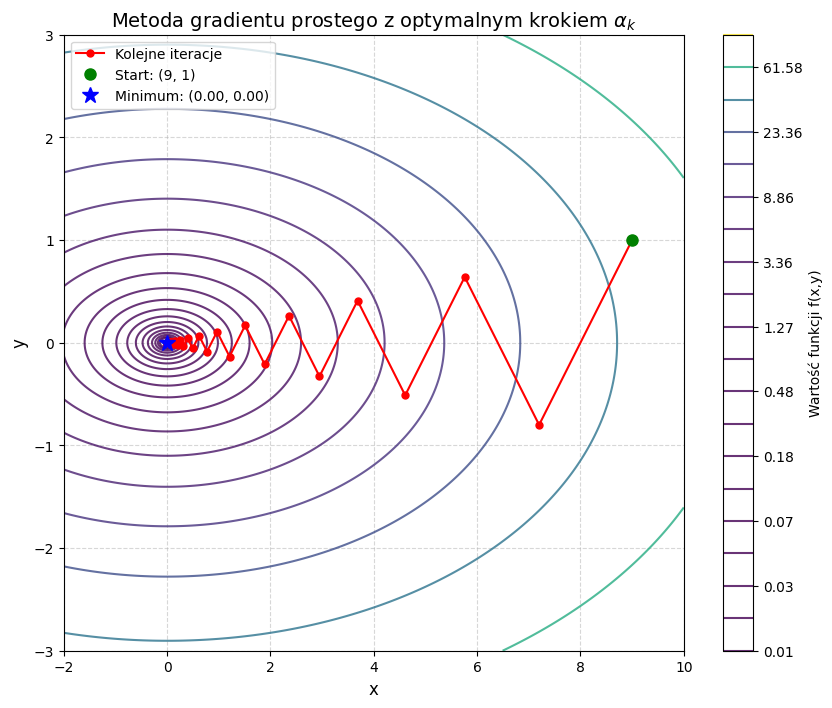

In [7]:
plt.figure(figsize=(10, 8))

levels = np.logspace(-2, 2, 20)
cp = plt.contour(X, Y, Z, levels=levels, cmap="viridis", alpha=0.8)
plt.colorbar(cp, label="Wartość funkcji f(x,y)")

plt.plot(
    path[:, 0], path[:, 1], "ro-", label="Kolejne iteracje", markersize=5, linewidth=1.5
)

plt.plot(path[0, 0], path[0, 1], "go", label="Start: (9, 1)", markersize=8)
plt.plot(
    path[-1, 0],
    path[-1, 1],
    "b*",
    label=f"Minimum: ({path[-1][0]:.2f}, {path[-1][1]:.2f})",
    markersize=12,
)

plt.title("Metoda gradientu prostego z optymalnym krokiem $\\alpha_k$", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()
